# Domain-of-validity (DoV) example

The `DoV` class computes Morgan fingerprints for polymer SMILES and counts how many fingerprints in a prediction set are missing from the training set. A high `fps_notin_train` means the model is extrapolating.

This notebook uses the bundled `stereopolymer_input_nopush.csv`. Run `quick_train_and_predict.ipynb` first to produce a holdout set, or simply split the bundled data inline as shown below.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from polyid import DoV

dov = DoV()

2026-06-24 11:59:24.475555: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-24 11:59:26.022006: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Fingerprint a single SMILES

`dov.get_fp(smiles)` returns a Series of Morgan fingerprint hashes -> occurrence count for the molecule.

In [2]:
smiles = "C=CCC(O)CCC(O)CC"
fp = dov.get_fp(smiles)
print(f"{len(fp)} unique fingerprints")
fp.head()

20 unique fingerprints


[11:59:46] DEPRECATION WARNING: please use MorganGenerator


535847852     1
864662311     2
1506563592    1
1506997381    1
1542633699    2
Name: C=CCC(O)CCC(O)CC, dtype: int64

## 2. Fingerprint a training set

Split the bundled stereopolymer data by `smiles_monomer` so train / test contain different polymer chemistries (a realistic generalisation test).

In [3]:
df = pd.read_csv("../data/stereopolymer_input_nopush.csv")

rng = np.random.default_rng(seed=0)
unique_monomers = df.smiles_monomer.unique()
test_pick = rng.choice(len(unique_monomers), size=max(1, int(0.2 * len(unique_monomers))), replace=False)
test_monomers = set(unique_monomers[test_pick])

dftrain = df[~df.smiles_monomer.isin(test_monomers)].reset_index(drop=True)
dftest = df[df.smiles_monomer.isin(test_monomers)].reset_index(drop=True)
print(f"train rows: {len(dftrain)} | test rows: {len(dftest)}")

train rows: 203 | test rows: 26


In [4]:
# Build a (rows x fingerprints) sparse-ish dataframe of train counts.
# Each column is one Morgan fingerprint hash, values are per-row occurrence counts.
dftrain_fps = dov.get_fps(dftrain)
print(f"train fingerprints shape: {dftrain_fps.shape}")
dftrain_fps.iloc[:5, :8]

  0%|          | 0/203 [00:00<?, ?it/s]

[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerat

[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerat

train fingerprints shape: (203, 190)


,3957343,74537039,80803194,96701530,98513984,130441644,211329868,284916952
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0


## 3. Count out-of-distribution fingerprints for the test set

`get_fps_overlap` appends a `fps_notin_train` column to the prediction dataframe: the number of Morgan fingerprints in each test polymer that never appeared in any training polymer. Use this as a per-polymer DoV score.

In [5]:
dftest_dov = dov.get_fps_overlap(dftest, dftrain_fps)
dftest_dov[["smiles_polymer", "smiles_monomer", "fps_notin_train"]].head()

  0%|          | 0/26 [00:00<?, ?it/s]

[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerat

[11:59:46] DEPRECATION WARNING: please use MorganGenerator
[11:59:46] DEPRECATION WARNING: please use MorganGenerator
100%|██████████| 26/26 [00:00<00:00, 840.14it/s]

,smiles_polymer,smiles_monomer,fps_notin_train
0,O=C(O)C[C@H](OC(=O)C[C@@H](OC(=O)C[C@H](OC(=O)...,O=C(O)C[C@@H](O)C(=O)OCc1ccccc1.O=C(O)C[C@H](O...,4
1,O=C(O)C[C@@H](OC(=O)C[C@H](OC(=O)C[C@@H](OC(=O...,O=C(O)C[C@@H](O)C(=O)OCc1ccccc1.O=C(O)C[C@H](O...,4
2,O=C(O)C[C@H](OC(=O)C[C@@H](OC(=O)C[C@@H](OC(=O...,O=C(O)C[C@@H](O)C(=O)OCc1ccccc1.O=C(O)C[C@H](O...,4
3,O=C(O)C[C@H](OC(=O)C[C@@H](OC(=O)C[C@@H](OC(=O...,O=C(O)C[C@@H](O)C(=O)OCc1ccccc1.O=C(O)C[C@H](O...,4
4,O=C(O)C[C@H](OC(=O)C[C@@H](OC(=O)C[C@H](OC(=O)...,O=C(O)C[C@@H](O)C(=O)OCc1ccccc1.O=C(O)C[C@H](O...,4


count    26.00
mean      5.54
std       2.35
min       4.00
25%       4.00
50%       4.00
75%       9.00
max       9.00
Name: fps_notin_train, dtype: float64


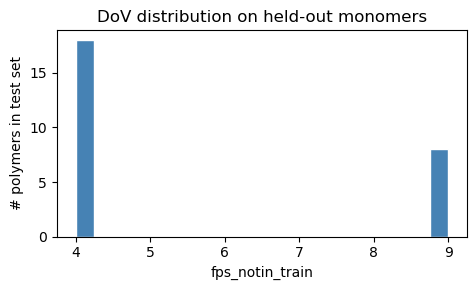

In [6]:
summary = dftest_dov.fps_notin_train.describe().round(2)
print(summary)

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(dftest_dov.fps_notin_train, bins=20, color="steelblue", edgecolor="white")
ax.set_xlabel("fps_notin_train")
ax.set_ylabel("# polymers in test set")
ax.set_title("DoV distribution on held-out monomers")
plt.tight_layout()

## 4. Use the DoV score to flag low-confidence predictions

A typical pattern: load trained models with `MultiModel.load_models(...)`, run `make_aggregate_predictions`, then merge `fps_notin_train` so downstream code can drop predictions above a configurable threshold (e.g. `fps_notin_train > 0`).

```python
from polyid import MultiModel
mm = MultiModel.load_models("./quick_train_models")
df_pred = mm.make_aggregate_predictions(dftest)
df_pred = df_pred.merge(
    dftest_dov[["smiles_polymer", "fps_notin_train"]].drop_duplicates("smiles_polymer"),
    on="smiles_polymer",
    how="left",
)
df_confident = df_pred[df_pred.fps_notin_train == 0]
```